<a href="https://colab.research.google.com/github/MwaringaJanji/Bike-Sales-Visualization-using-Powe-BI/blob/main/Nyali_Vipingo_Migration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from google.colab import files

uploaded = files.upload()  # select STATISTIC_REAL_ESTATE.xlsx in the dialog
filename = list(uploaded.keys())[0]
print("Uploaded:", filename)

Saving STATISTIC REAL ESTATE.xlsx to STATISTIC REAL ESTATE (1).xlsx
Uploaded: STATISTIC REAL ESTATE (1).xlsx


In [25]:
from google.colab import drive
drive.mount('/content/drive')

# Edit this path to wherever you put the file in Drive
filename = "/content/drive/MyDrive/STATISTIC_REAL_ESTATE.xlsx"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
import pandas as pd

xls = ('/content/STATISTIC REAL ESTATE.xlsx')
sheet1 = pd.read_excel(xls, sheet_name="Sheet1")
display(sheet1)
sheet2 = pd.read_excel(xls, sheet_name="Sheet2")
display(sheet2)


,Statistic,Value,Year
0,Nyali avg land price (per plot),60600000,2026
1,Vipingo avg land price (per plot),22200000,2026
2,Vipingo avg house price,44700000,2026
3,Nyali min plot price,15000000,2023
4,Vipingo land price growth (5yr),~25%,2020–2025
5,Diani land price growth (5yr),~79.1%,2020–2025
6,Watamu land price growth (5yr),~70%,2020–2025
7,Nyali beachfront premium over avg,0.19,2026
8,Nyali constituency population,216577,2019
9,Vipingo SEZ projected direct jobs,"35,000+",2025 (proj.)


,STATISTIC,PRICE(KES)
0,Nyali land price (avg plot),60600000
1,Vipingo land price (avg plot),22200000
2,Vipingo house price (avg),44700000
3,Nyali constituency pop.,216577
4,Vipingo price growth (5yr),0.25
5,SEZ direct jobs projected,"35,000+"
6,SEZ investment expected,390000000000
7,SEZ area,"2,000ac"
8,Typical Nyali sale (4BR),70000000
9,Typical Vipingo purchase (4BR),35000000


In [48]:
import re
import numpy as np

def parse_value(raw):
    """Turn a messy statistic string into (numeric_value, unit, is_estimate)."""
    if pd.isna(raw):
        return np.nan, "unknown", False

    if isinstance(raw, (int, float)):
        return float(raw), "KES_or_count", False

    s = str(raw).strip()
    is_estimate = s.startswith("~") or s.endswith("+")
    s_clean = s.replace("~", "").replace("+", "").replace(",", "").strip()

    if "%" in s_clean:
        num = float(s_clean.replace("%", ""))
        return num / 100.0, "percent", is_estimate

    if "acre" in s_clean.lower():
        num = float(re.search(r"[\d.]+", s_clean).group())
        return num, "acres", is_estimate

    if "/plot" in s_clean.lower():
        num = float(re.search(r"[\d.]+", s_clean).group())
        return num, "KES_per_plot", is_estimate

    try:
        return float(s_clean), "KES_or_count", is_estimate
    except ValueError:
        return np.nan, "unparsed", is_estimate


In [50]:
sheet1[['cleaned_value', 'unit', 'is_estimate']] = sheet1['Value'].apply(lambda x: pd.Series(parse_value(x)))

print("Sheet1 with parsed values:")
display(sheet1.head())

Sheet1 with parsed values:


,Statistic,Value,Year,cleaned_value,unit,is_estimate
0,Nyali avg land price (per plot),60600000,2026,60600000.00,KES_or_count,False
1,Vipingo avg land price (per plot),22200000,2026,22200000.00,KES_or_count,False
2,Vipingo avg house price,44700000,2026,44700000.00,KES_or_count,False
3,Nyali min plot price,15000000,2023,15000000.00,KES_or_count,False
4,Vipingo land price growth (5yr),~25%,2020–2025,0.25,percent,True


In [51]:
unparsed_or_unknown_rows = sheet1[(sheet1['unit'] == 'unparsed') | (sheet1['unit'] == 'unknown')]

if not unparsed_or_unknown_rows.empty:
    print("Rows with 'unparsed' or 'unknown' units:")
    display(unparsed_or_unknown_rows)
else:
    print("No rows found with 'unparsed' or 'unknown' units.")

No rows found with 'unparsed' or 'unknown' units.


In [52]:
print("Data type of 'cleaned_value' column:", sheet1['cleaned_value'].dtype)
print("Number of NaN values in 'cleaned_value' column:", sheet1['cleaned_value'].isna().sum())

Data type of 'cleaned_value' column: float64
Number of NaN values in 'cleaned_value' column: 0


In [53]:
nyali_avg_land_price = sheet1.loc[sheet1['Statistic'] == 'Nyali avg land price (per plot)', 'cleaned_value'].iloc[0]
vipingo_avg_land_price = sheet1.loc[sheet1['Statistic'] == 'Vipingo avg land price (per plot)', 'cleaned_value'].iloc[0]
vipingo_early_land_price_2004 = sheet1.loc[sheet1['Statistic'] == 'Vipingo early land price (2004 era)', 'cleaned_value'].iloc[0]
nyali_4br_sale_price_2014 = sheet1.loc[sheet1['Statistic'] == 'Typical Nyali 4BR sale price (2014)', 'cleaned_value'].iloc[0]
vipingo_4br_purchase_2014 = sheet1.loc[sheet1['Statistic'] == 'Typical Vipingo 4BR purchase (2014)', 'cleaned_value'].iloc[0]

print(f"Nyali Average Land Price (2026): KSh {nyali_avg_land_price:,.2f}")
print(f"Vipingo Average Land Price (2026): KSh {vipingo_avg_land_price:,.2f}")
print(f"Vipingo Early Land Price (2004 era): KSh {vipingo_early_land_price_2004:,.2f}")
print(f"Typical Nyali 4BR Sale Price (2014): KSh {nyali_4br_sale_price_2014:,.2f}")
print(f"Typical Vipingo 4BR Purchase (2014): KSh {vipingo_4br_purchase_2014:,.2f}")

Nyali Average Land Price (2026): KSh 60,600,000.00
Vipingo Average Land Price (2026): KSh 22,200,000.00
Vipingo Early Land Price (2004 era): KSh 100,000.00
Typical Nyali 4BR Sale Price (2014): KSh 70,000,000.00
Typical Vipingo 4BR Purchase (2014): KSh 35,000,000.00


In [54]:
percentage_growth_vipingo = ((vipingo_avg_land_price - vipingo_early_land_price_2004) / vipingo_early_land_price_2004) * 100
print(f"Percentage growth in Vipingo land price from 2004 to 2026: {percentage_growth_vipingo:.2f}%")

Percentage growth in Vipingo land price from 2004 to 2026: 22100.00%


In [55]:
import numpy as np

# Define the years for the CAGR calculation
start_year = 2004
end_year = 2026

# Calculate the number of years
num_years = end_year - start_year

# Calculate CAGR
cagr_vipingo = ((vipingo_avg_land_price / vipingo_early_land_price_2004)**(1/num_years)) - 1

print(f"Annualised Growth Rate (CAGR) for Vipingo land prices from {start_year} to {end_year}: {cagr_vipingo:.2%}")

Annualised Growth Rate (CAGR) for Vipingo land prices from 2004 to 2026: 27.84%


In [79]:
# Calculate the gross arbitrage profit for an 'apples-to-apples' land-for-land trade today (2026)
# This assumes selling a Nyali plot and buying a Vipingo plot at current market prices.
current_apples_to_apples_arbitrage = nyali_avg_land_price - vipingo_avg_land_price

print(f"Nyali Average Land Price (2026): KSh {nyali_avg_land_price:,.2f}")
print(f"Vipingo Average Land Price (2026): KSh {vipingo_avg_land_price:,.2f}")
print(f"\nDeterministic 'Apples-to-Apples' Arbitrage Profit (2026): KSh {current_apples_to_apples_arbitrage:,.2f}")

if current_apples_to_apples_arbitrage > 0:
    print("This indicates a positive arbitrage opportunity by selling in Nyali and buying in Vipingo today.")
elif current_apples_to_apples_arbitrage < 0:
    print("This indicates a negative arbitrage opportunity, meaning Nyali land is more expensive than Vipingo land today.")
else:
    print("There is no arbitrage opportunity, as prices are equal.")

Nyali Average Land Price (2026): KSh 60,600,000.00
Vipingo Average Land Price (2026): KSh 22,200,000.00

Deterministic 'Apples-to-Apples' Arbitrage Profit (2026): KSh 38,400,000.00
This indicates a positive arbitrage opportunity by selling in Nyali and buying in Vipingo today.


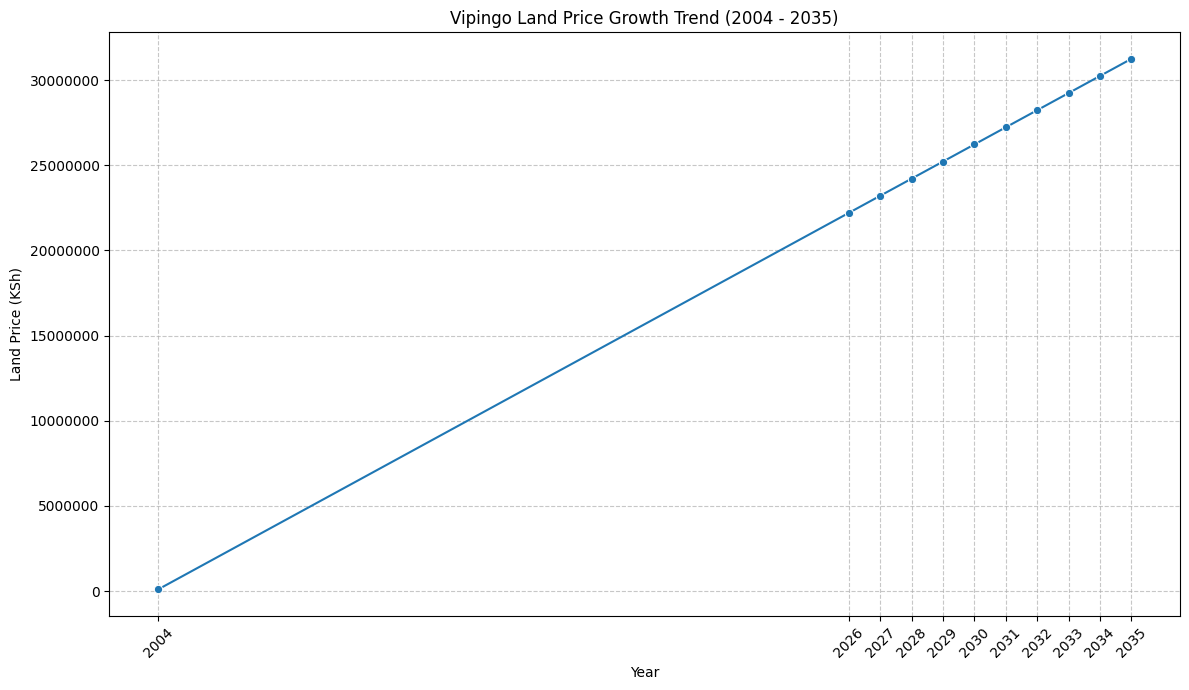

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting the historical and predicted Vipingo land prices
plot_data = pd.DataFrame({
    'Year': [start_year, end_year] + list(future_years.flatten()),
    'Price': [vipingo_early_land_price_2004, vipingo_avg_land_price] + list(predicted_prices)
})

# Ensure Year is an integer for plotting
plot_data['Year'] = plot_data['Year'].astype(int)

# Create the plot
plt.figure(figsize=(12, 7))
sns.lineplot(x='Year', y='Price', data=plot_data, marker='o')

# Add titles and labels
plt.title('Vipingo Land Price Growth Trend (2004 - 2035)')
plt.xlabel('Year')
plt.ylabel('Land Price (KSh)')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(plot_data['Year'].unique(), rotation=45)
plt.tight_layout()
plt.show()

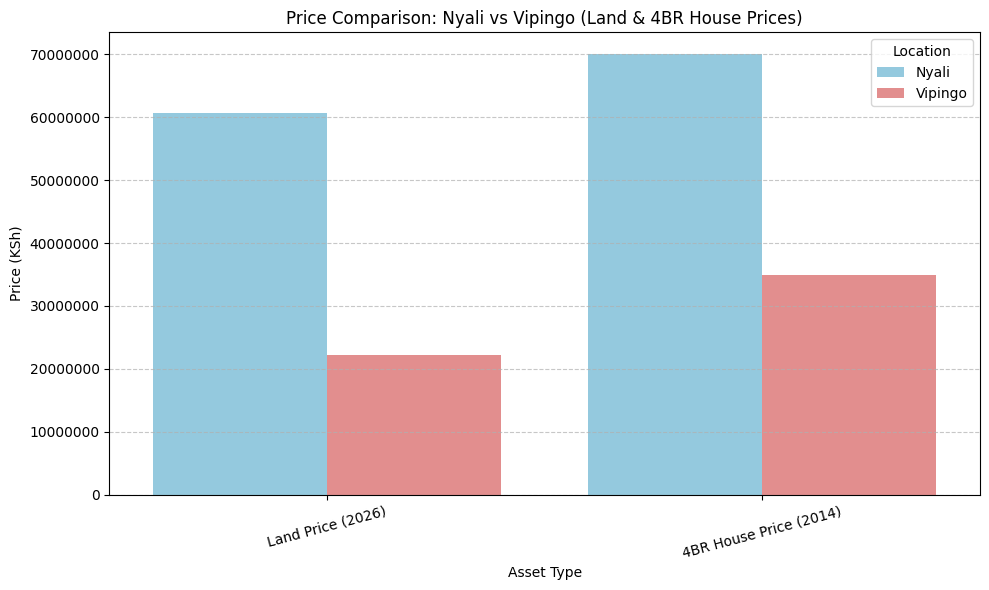

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Price comparison — Nyali vs Vipingo land/house prices today
# Data from previous extraction
prices_data = {
    'Location': ['Nyali', 'Vipingo', 'Nyali', 'Vipingo'],
    'Type': ['Land Price (2026)', 'Land Price (2026)', '4BR House Price (2014)', '4BR House Price (2014)'],
    'Price': [nyali_avg_land_price, vipingo_avg_land_price, nyali_4br_sale_price_2014, vipingo_4br_purchase_2014]
}
price_df = pd.DataFrame(prices_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Type', y='Price', hue='Location', data=price_df, palette={'Nyali': 'skyblue', 'Vipingo': 'lightcoral'})
plt.title('Price Comparison: Nyali vs Vipingo (Land & 4BR House Prices)')
plt.xlabel('Asset Type')
plt.ylabel('Price (KSh)')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Location')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

The 2014 arbitrage opportunity (Nyali 4BR sale price - Vipingo 4BR purchase price)

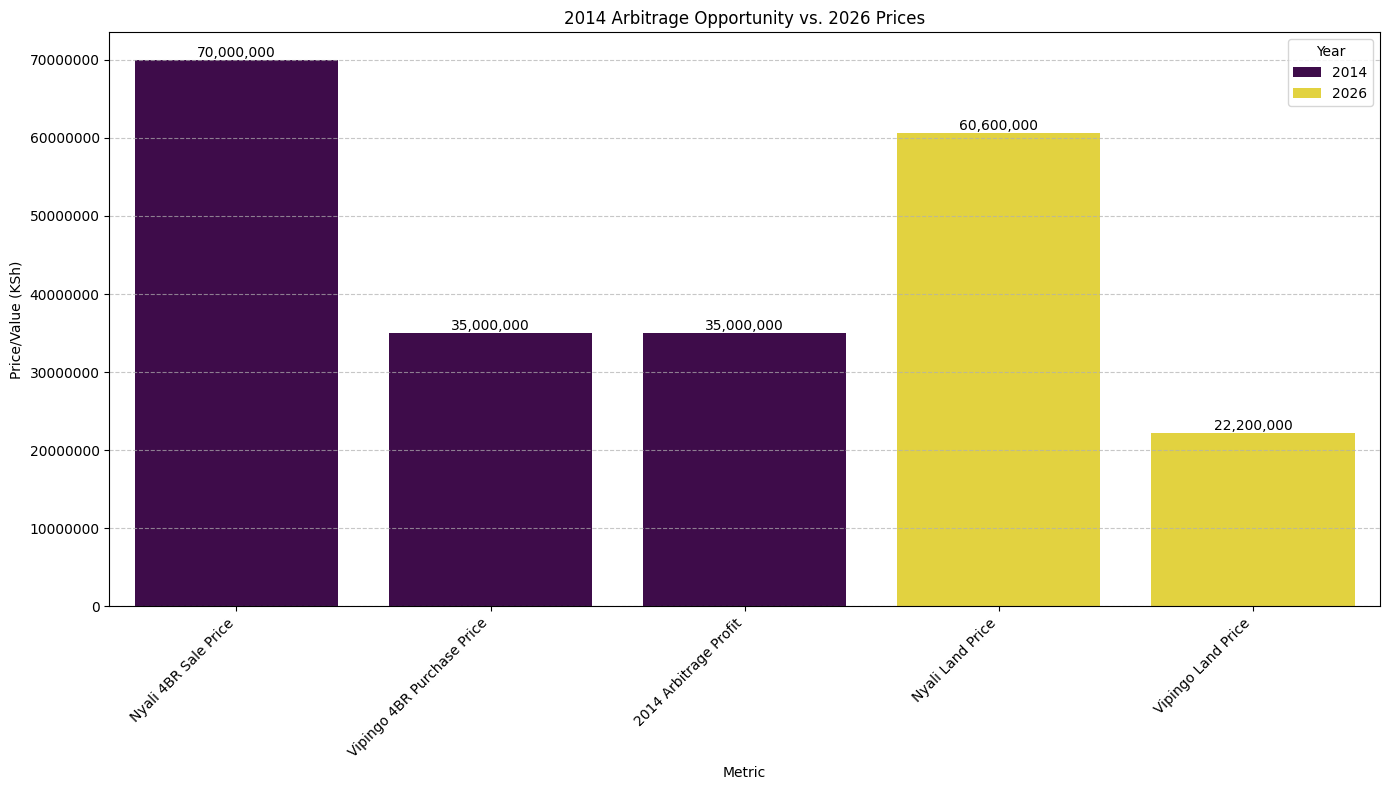

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the 2014 arbitrage opportunity (Nyali 4BR sale price - Vipingo 4BR purchase price)
arbitrage_2014 = nyali_4br_sale_price_2014 - vipingo_4br_purchase_2014

# Prepare data for plotting
arbitrage_data = pd.DataFrame({
    'Metric': [
        'Nyali 4BR Sale Price',
        'Vipingo 4BR Purchase Price',
        '2014 Arbitrage Profit',
        'Nyali Land Price',
        'Vipingo Land Price'
    ],
    'Year': [2014, 2014, 2014, 2026, 2026],
    'Value': [
        nyali_4br_sale_price_2014,
        vipingo_4br_purchase_2014,
        arbitrage_2014,
        nyali_avg_land_price,
        vipingo_avg_land_price
    ]
})

plt.figure(figsize=(14, 8))
sns.barplot(x='Metric', y='Value', hue='Year', data=arbitrage_data, palette='viridis')
plt.title('2014 Arbitrage Opportunity vs. 2026 Prices')
plt.xlabel('Metric')
plt.ylabel('Price/Value (KSh)')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')

# Adding value labels on top of bars
for index, row in arbitrage_data.iterrows():
    plt.text(index, row['Value'], f'{row["Value"]:,.0f}', color='black', ha="center", va="bottom")

plt.tight_layout()
plt.show()

Scenario Model: Bull/Base/Bear Assumptions for Vipingo's Future Growth


--- Scenario Model for Arbitrage Profit (Projected to 2035) ---
Current Vipingo Land Price (2026): KSh 22,200,000.00
Nyali Average Land Price (Today): KSh 60,600,000.00
Total Transaction Cost Rate: 0.00%

Scenario: Bear (Growth Rate: 20.88%)
  Projected Vipingo Price (2035): KSh 122,303,973.89
  Gross Arbitrage Profit: KSh -61,703,973.89
  Total Transaction Costs: KSh 0.00
  Net Arbitrage Profit: KSh -61,703,973.89

Scenario: Base (Growth Rate: 27.84%)
  Projected Vipingo Price (2035): KSh 202,406,588.86
  Gross Arbitrage Profit: KSh -141,806,588.86
  Total Transaction Costs: KSh 0.00
  Net Arbitrage Profit: KSh -141,806,588.86

Scenario: Bull (Growth Rate: 34.79%)
  Projected Vipingo Price (2035): KSh 326,143,598.38
  Gross Arbitrage Profit: KSh -265,543,598.38
  Total Transaction Costs: KSh 0.00
  Net Arbitrage Profit: KSh -265,543,598.38



,Scenario,Projected Vipingo Price,Gross Arbitrage Profit,Total Transaction Costs,Net Arbitrage Profit
0,Bear,1.223040e+08,-6.170397e+07,0.0,-6.170397e+07
1,Base,2.024066e+08,-1.418066e+08,0.0,-1.418066e+08
2,Bull,3.261436e+08,-2.655436e+08,0.0,-2.655436e+08


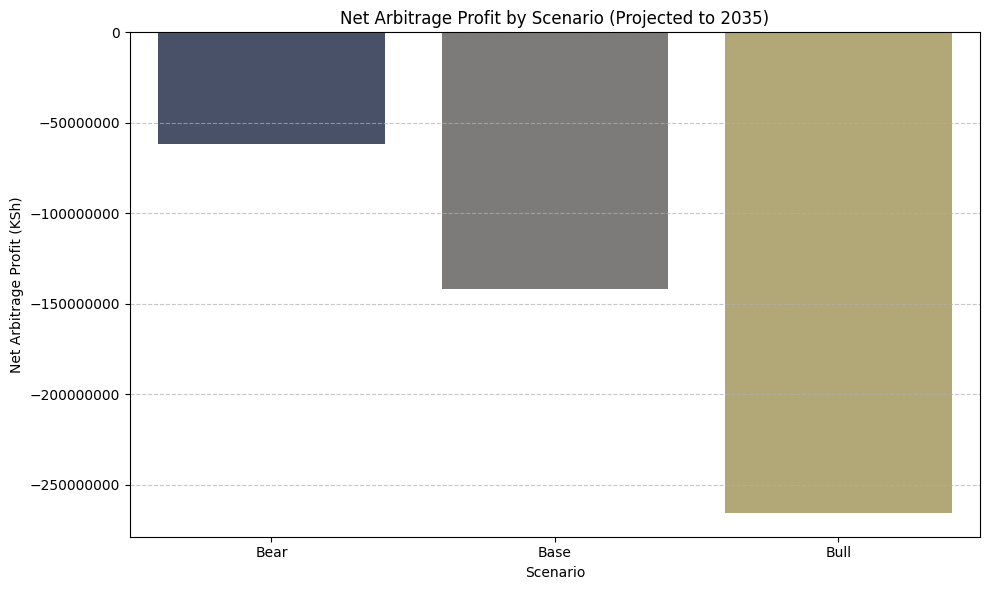

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define scenario growth rates for Vipingo land prices (annual)
# Base rate can be the previously calculated CAGR or a moderate assumption
base_growth_rate = cagr_vipingo # Using the CAGR calculated earlier
bull_growth_rate = base_growth_rate * 1.25 # 25% higher than base
bear_growth_rate = base_growth_rate * 0.75 # 25% lower than base

# Target year for projection (e.g., 2035, consistent with earlier prediction)
projection_year = 2035
current_year = 2026
years_to_project = projection_year - current_year

# Initialize a list to store scenario results
scenario_results = []

# Re-extract transaction costs (with error handling)
legal_fees_row = sheet1.loc[sheet1['Statistic'] == 'Legal fees (per transaction)', 'cleaned_value']
valuation_fees_row = sheet1.loc[sheet1['Statistic'] == 'Valuation fees (per transaction)', 'cleaned_value']

if not legal_fees_row.empty and not valuation_fees_row.empty:
    legal_fees_percent = legal_fees_row.iloc[0]
    valuation_fees_percent = valuation_fees_row.iloc[0]
    total_transaction_cost_rate = legal_fees_percent + valuation_fees_percent
else:
    print("Warning: Transaction cost statistics not found. Using default 0% for scenarios.")
    total_transaction_cost_rate = 0.0


scenarios = {
    'Bear': bear_growth_rate,
    'Base': base_growth_rate,
    'Bull': bull_growth_rate
}

print(f"\n--- Scenario Model for Arbitrage Profit (Projected to {projection_year}) ---")
print(f"Current Vipingo Land Price ({current_year}): KSh {vipingo_avg_land_price:,.2f}")
print(f"Nyali Average Land Price (Today): KSh {nyali_avg_land_price:,.2f}")
print(f"Total Transaction Cost Rate: {total_transaction_cost_rate:.2%}\n")

for scenario_name, growth_rate in scenarios.items():
    # Project Vipingo land price for the target year
    projected_vipingo_price = vipingo_avg_land_price * ((1 + growth_rate)**years_to_project)

    # Calculate gross arbitrage profit for the scenario
    gross_arbitrage_profit = nyali_avg_land_price - projected_vipingo_price

    # Calculate transaction costs for this scenario
    costs_on_vipingo_purchase = projected_vipingo_price * total_transaction_cost_rate
    costs_on_nyali_sale = nyali_avg_land_price * total_transaction_cost_rate
    total_scenario_transaction_costs = costs_on_vipingo_purchase + costs_on_nyali_sale

    # Calculate net arbitrage profit for the scenario
    net_arbitrage_profit = gross_arbitrage_profit - total_scenario_transaction_costs

    scenario_results.append({
        'Scenario': scenario_name,
        'Projected Vipingo Price': projected_vipingo_price,
        'Gross Arbitrage Profit': gross_arbitrage_profit,
        'Total Transaction Costs': total_scenario_transaction_costs,
        'Net Arbitrage Profit': net_arbitrage_profit
    })

    print(f"Scenario: {scenario_name} (Growth Rate: {growth_rate:.2%})")
    print(f"  Projected Vipingo Price ({projection_year}): KSh {projected_vipingo_price:,.2f}")
    print(f"  Gross Arbitrage Profit: KSh {gross_arbitrage_profit:,.2f}")
    print(f"  Total Transaction Costs: KSh {total_scenario_transaction_costs:,.2f}")
    print(f"  Net Arbitrage Profit: KSh {net_arbitrage_profit:,.2f}\n")

scenario_df = pd.DataFrame(scenario_results)
display(scenario_df)

# Plotting the net arbitrage profit across scenarios
plt.figure(figsize=(10, 6))
sns.barplot(x='Scenario', y='Net Arbitrage Profit', data=scenario_df, palette='cividis')
plt.title(f'Net Arbitrage Profit by Scenario (Projected to {projection_year})')
plt.xlabel('Scenario')
plt.ylabel('Net Arbitrage Profit (KSh)')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Monte Carlo Simulation: Distribution of Outcomes

--- Monte Carlo Simulation Results for Net Arbitrage Profit (Projected to 2035) ---
Number of Simulations: 10000
Projected Years: 9

Mean Net Arbitrage Profit: KSh -174,707,994.85
Median Net Arbitrage Profit: KSh -151,138,929.82
Standard Deviation of Net Arbitrage Profit: KSh 117,221,103.08

Percentiles of Net Arbitrage Profit:
  5th Percentile: KSh -395,378,472.90
 25th Percentile: KSh -234,361,037.63
 50th Percentile: KSh -151,138,929.82
 75th Percentile: KSh -90,566,815.69
 95th Percentile: KSh -31,540,578.92

Probability of Positive Net Arbitrage Profit: 0.88%



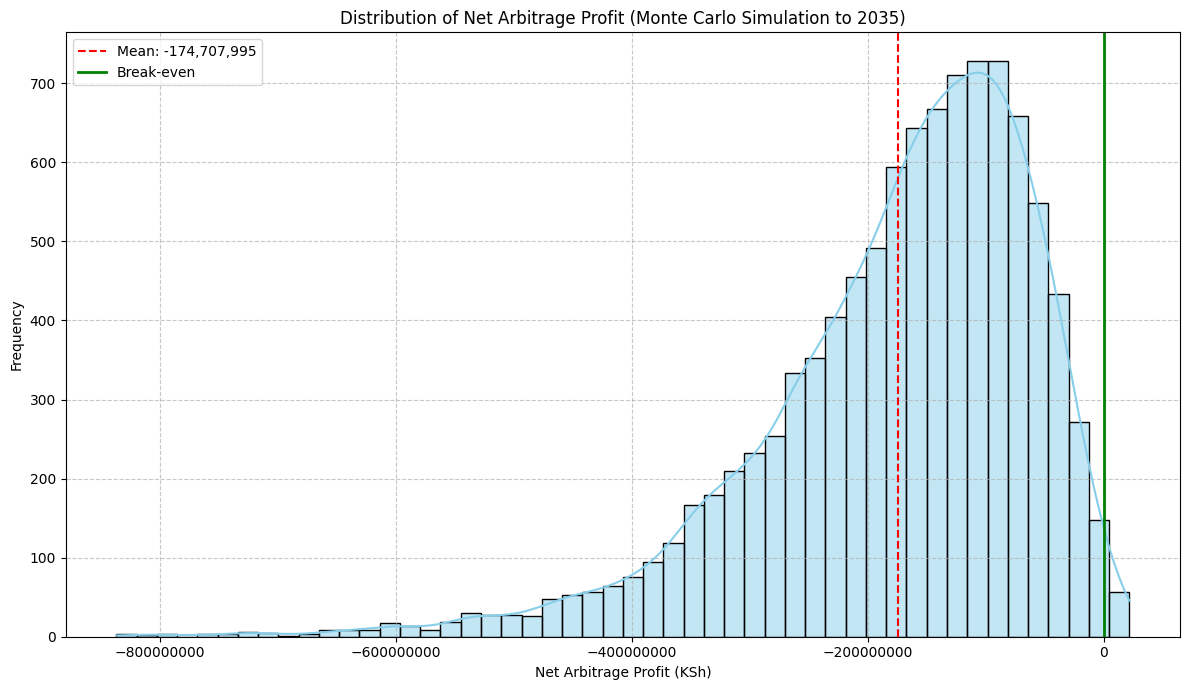

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Simulation Parameters ---
num_simulations = 10000
projection_year = 2035
current_year = 2026
years_to_project = projection_year - current_year

# --- Input Values (from previous cells) ---
# nyali_avg_land_price (2026 price of Nyali)
# vipingo_avg_land_price (2026 price of Vipingo)
# cagr_vipingo (Base growth rate for Vipingo)

# --- Define Distributions for Random Variables ---

# Vipingo Annual Growth Rate (Normal distribution, clipped)
# Mean based on calculated CAGR
mean_vipingo_growth = cagr_vipingo
# Standard deviation: A reasonable spread, e.g., 25% of the mean
std_vipingo_growth = cagr_vipingo * 0.25 # Adjust as needed for desired volatility
min_vipingo_growth = 0.0 # Growth rate cannot be negative
max_vipingo_growth = 0.50 # Cap at 50% for realism

# Transaction Cost Rate (Uniform distribution for each transaction: buy OR sell)
# Since specific fees were not found in sheet1, using plausible default ranges.
min_transaction_cost_rate = 0.02  # 2% of property value
max_transaction_cost_rate = 0.06  # 6% of property value

# --- Monte Carlo Simulation ---
net_arbitrage_profits = []

for _ in range(num_simulations):
    # 1. Simulate Vipingo Annual Growth Rate
    random_vipingo_growth_rate = np.random.normal(mean_vipingo_growth, std_vipingo_growth)
    random_vipingo_growth_rate = np.clip(random_vipingo_growth_rate, min_vipingo_growth, max_vipingo_growth)

    # 2. Simulate Transaction Costs for Purchase and Sale
    # Cost for buying Vipingo
    purchase_transaction_cost_rate = np.random.uniform(min_transaction_cost_rate, max_transaction_cost_rate)
    # Cost for selling Vipingo (implied future transaction for comparison)
    sale_transaction_cost_rate = np.random.uniform(min_transaction_cost_rate, max_transaction_cost_rate)

    # Project Vipingo's future price
    # This is the value of the Vipingo property after 'years_to_project' years
    projected_vipingo_value = vipingo_avg_land_price * ((1 + random_vipingo_growth_rate)**years_to_project)

    # Calculate gross arbitrage profit (consistent with scenario model: Nyali current value - Vipingo future value)
    gross_arbitrage_profit = nyali_avg_land_price - projected_vipingo_value

    # Calculate total transaction costs for the Vipingo investment side
    # Cost incurred on the Vipingo property (initial purchase + implied future sale)
    total_transaction_costs = (vipingo_avg_land_price * purchase_transaction_cost_rate) + \
                              (projected_vipingo_value * sale_transaction_cost_rate)

    # Calculate net arbitrage profit
    net_profit = gross_arbitrage_profit - total_transaction_costs
    net_arbitrage_profits.append(net_profit)

# Convert results to a Series for easier analysis
net_arbitrage_profits_series = pd.Series(net_arbitrage_profits)

# --- Analysis and Visualization ---

print(f"--- Monte Carlo Simulation Results for Net Arbitrage Profit (Projected to {projection_year}) ---")
print(f"Number of Simulations: {num_simulations}")
print(f"Projected Years: {years_to_project}\n")

print(f"Mean Net Arbitrage Profit: KSh {net_arbitrage_profits_series.mean():,.2f}")
print(f"Median Net Arbitrage Profit: KSh {net_arbitrage_profits_series.median():,.2f}")
print(f"Standard Deviation of Net Arbitrage Profit: KSh {net_arbitrage_profits_series.std():,.2f}\n")

print("Percentiles of Net Arbitrage Profit:")
print(f"  5th Percentile: KSh {net_arbitrage_profits_series.quantile(0.05):,.2f}")
print(f" 25th Percentile: KSh {net_arbitrage_profits_series.quantile(0.25):,.2f}")
print(f" 50th Percentile: KSh {net_arbitrage_profits_series.quantile(0.50):,.2f}")
print(f" 75th Percentile: KSh {net_arbitrage_profits_series.quantile(0.75):,.2f}")
print(f" 95th Percentile: KSh {net_arbitrage_profits_series.quantile(0.95):,.2f}\n")

# Probability of positive profit
prob_positive_profit = (net_arbitrage_profits_series > 0).mean() * 100
print(f"Probability of Positive Net Arbitrage Profit: {prob_positive_profit:.2f}%\n")

# Plotting the distribution of net arbitrage profits
plt.figure(figsize=(12, 7))
sns.histplot(net_arbitrage_profits_series, bins=50, kde=True, color='skyblue')
plt.title(f'Distribution of Net Arbitrage Profit (Monte Carlo Simulation to {projection_year})')
plt.xlabel('Net Arbitrage Profit (KSh)')
plt.ylabel('Frequency')
plt.ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis
plt.axvline(net_arbitrage_profits_series.mean(), color='red', linestyle='--', label=f'Mean: {net_arbitrage_profits_series.mean():,.0f}')
plt.axvline(0, color='green', linestyle='-', linewidth=2, label='Break-even')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Comparison: 2014 House Arbitrage vs. 2026 Land Arbitrage

2014 House-for-House Arbitrage Profit: KSh 35,000,000.00
2026 Land-for-Land Arbitrage Profit: KSh 38,400,000.00

--- Comparison ---
The 2026 Land Arbitrage Profit (KSh 38,400,000.00) is higher than the 2014 House Arbitrage Profit (KSh 35,000,000.00) by KSh 3,400,000.00.


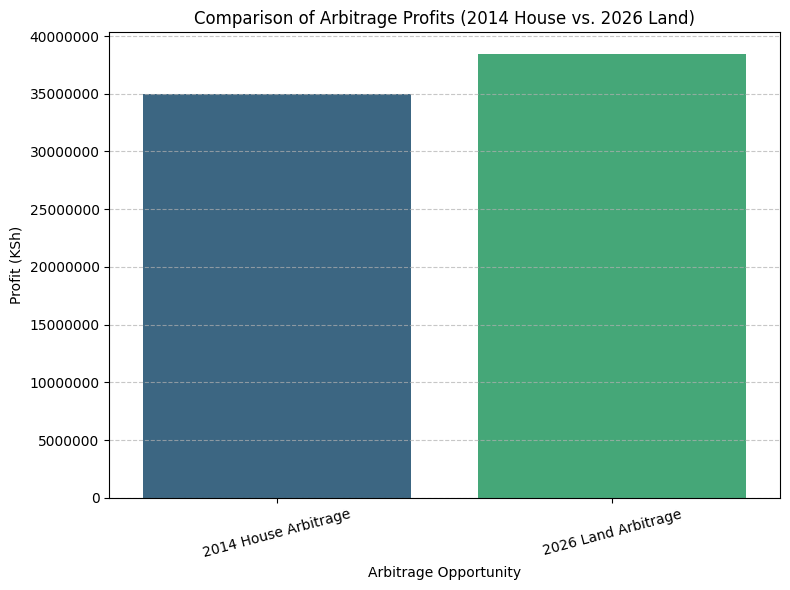

In [81]:
# Retrieve the calculated arbitrage profits
# 2014 house arbitrage profit (from previous calculation)
profit_2014_house = arbitrage_2014 # This variable stores 35,000,000.0

# 2026 land arbitrage profit (from previous calculation, 'apples-to-apples')
profit_2026_land = current_apples_to_apples_arbitrage # This variable stores 38,400,000.0

print(f"2014 House-for-House Arbitrage Profit: KSh {profit_2014_house:,.2f}")
print(f"2026 Land-for-Land Arbitrage Profit: KSh {profit_2026_land:,.2f}")

print("\n--- Comparison ---")
if profit_2026_land > profit_2014_house:
    print(f"The 2026 Land Arbitrage Profit (KSh {profit_2026_land:,.2f}) is higher than the 2014 House Arbitrage Profit (KSh {profit_2014_house:,.2f}) by KSh {profit_2026_land - profit_2014_house:,.2f}.")
elif profit_2026_land < profit_2014_house:
    print(f"The 2014 House Arbitrage Profit (KSh {profit_2014_house:,.2f}) is higher than the 2026 Land Arbitrage Profit (KSh {profit_2026_land:,.2f}) by KSh {profit_2014_house - profit_2026_land:,.2f}.")
else:
    print("Both arbitrage opportunities yield the same profit.")

# Visualize the comparison
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

comparison_df = pd.DataFrame({
    'Opportunity': ['2014 House Arbitrage', '2026 Land Arbitrage'],
    'Profit': [profit_2014_house, profit_2026_land]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Opportunity', y='Profit', data=comparison_df, palette='viridis')
plt.title('Comparison of Arbitrage Profits (2014 House vs. 2026 Land)')
plt.xlabel('Arbitrage Opportunity')
plt.ylabel('Profit (KSh)')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Sensitivity Analysis: Break-Even Vipingo Growth Rate

Approximate Break-Even Vipingo Annual Growth Rate: 11.13%


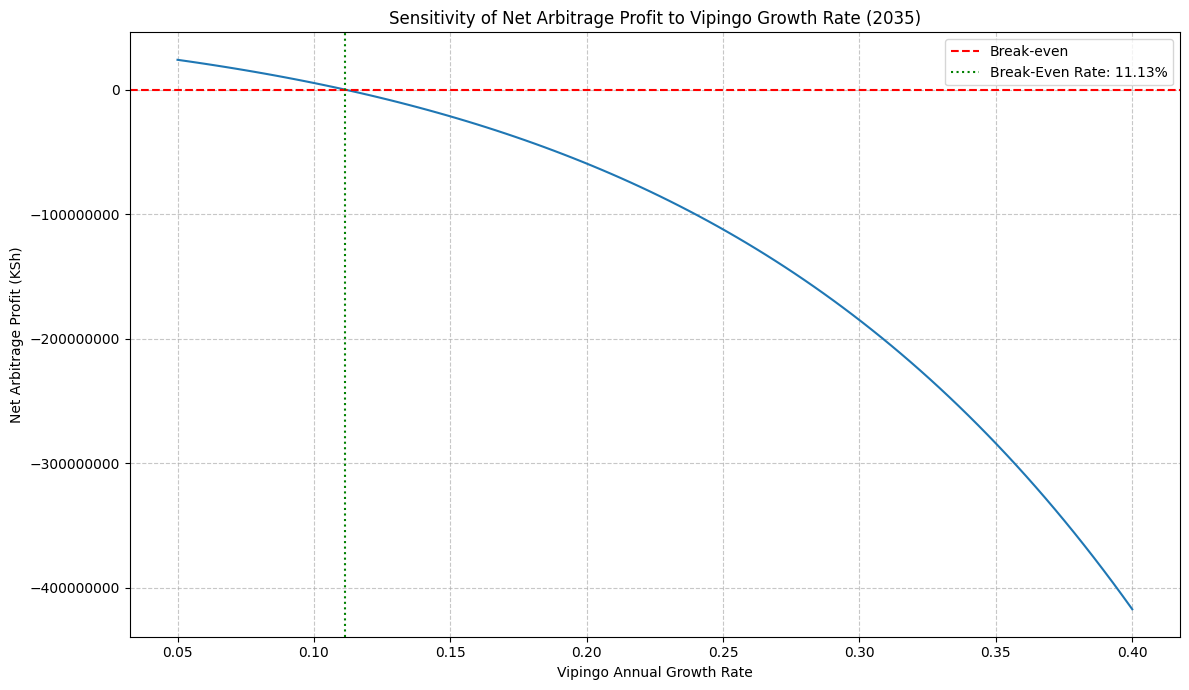

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Parameters for Sensitivity Analysis ---
projection_year = 2035
current_year = 2026
years_to_project = projection_year - current_year

# Fixed Nyali current land price
# nyali_avg_land_price (from previous cells)

# Fixed Vipingo current land price
# vipingo_avg_land_price (from previous cells)

# Transaction Cost Rate: Use the average of the min/max range from Monte Carlo
average_transaction_cost_rate = (min_transaction_cost_rate + max_transaction_cost_rate) / 2

# Define a range of Vipingo annual growth rates to test
growth_rate_range = np.linspace(0.05, 0.40, 100) # From 5% to 40% annual growth

sensitivity_results = []

for growth_rate in growth_rate_range:
    # Project Vipingo's future price
    projected_vipingo_value = vipingo_avg_land_price * ((1 + growth_rate)**years_to_project)

    # Calculate gross arbitrage profit
    gross_arbitrage_profit = nyali_avg_land_price - projected_vipingo_value

    # Calculate total transaction costs (purchase + implied future sale)
    total_transaction_costs = (vipingo_avg_land_price * average_transaction_cost_rate) + \
                              (projected_vipingo_value * average_transaction_cost_rate)

    # Calculate net arbitrage profit
    net_profit = gross_arbitrage_profit - total_transaction_costs
    sensitivity_results.append({
        'Vipingo Growth Rate': growth_rate,
        'Projected Vipingo Value': projected_vipingo_value,
        'Net Arbitrage Profit': net_profit
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

# --- Analysis and Visualization ---

plt.figure(figsize=(12, 7))
sns.lineplot(x='Vipingo Growth Rate', y='Net Arbitrage Profit', data=sensitivity_df)
plt.title(f'Sensitivity of Net Arbitrage Profit to Vipingo Growth Rate ({projection_year})')
plt.xlabel('Vipingo Annual Growth Rate')
plt.ylabel('Net Arbitrage Profit (KSh)')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.axhline(0, color='red', linestyle='--', label='Break-even')

# Find the break-even point
# Interpolate to find where Net Arbitrage Profit is zero
break_even_growth_rate = np.interp(0, sensitivity_df['Net Arbitrage Profit'].values[::-1],
                                     sensitivity_df['Vipingo Growth Rate'].values[::-1])

if break_even_growth_rate < growth_rate_range.min() or break_even_growth_rate > growth_rate_range.max():
    print("Break-even growth rate is outside the analyzed range.")
else:
    plt.axvline(break_even_growth_rate, color='green', linestyle=':',
                label=f'Break-Even Rate: {break_even_growth_rate:.2%}')
    print(f"Approximate Break-Even Vipingo Annual Growth Rate: {break_even_growth_rate:.2%}")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()